In [2]:
install.packages('aplot')

also installing the dependencies ‘gridGraphics’, ‘ggfun’, ‘ggplotify’, ‘patchwork’, ‘yulab.utils’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [3]:
library(tidyverse)
library(data.table)
library(cowplot)
library(aplot)

aplot v0.2.9 For help: https://github.com/YuLab-SMU/aplot/issues

If you use aplot in published research, please cite the paper:

Shuangbin Xu, Qianwen Wang, Shaodi Wen, Junrui Li, Nan He, Ming Li,
Thomas Hackl, Rui Wang, Dongqiang Zeng, Shixiang Wang, Shensuo Li,
Chunhui Gao, Lang Zhou, Shaoguo Tao, Zijing Xie, Lin Deng, and
Guangchuang Yu. aplot: Simplifying the creation of complex graphs to
visualize associations across diverse data types. The Innovation. 2025,
6(9):100958. doi: 10.1016/j.xinn.2025.100958

Export the citation to BibTex by citation('aplot')

This message can be suppressed by:
suppressPackageStartupMessages(library(aplot))



In [81]:
path_to_master_file <- '~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC_MQ.tsv'

In [82]:
per_sample_stats_df <-
fread(path_to_master_file)

In [83]:
per_sample_stats_df <- per_sample_stats_df %>%
mutate(good_sample = ifelse(cov_chrA >= 10 & good_frac_cov == T, T, F))

In [90]:
per_sample_stats_df %>%
group_by(good_sample) %>%
summarise(N = n())

good_sample,N
<lgl>,<int>
FALSE,1251
TRUE,1989


In [84]:
hist_x <- per_sample_stats_df %>%

ggplot()+
geom_histogram(aes(x = cov_chrA, fill = good_sample), binwidth = 0.02)+
scale_fill_manual(values = c('darkgrey', 'darkorange'))+
scale_x_log10()+
ylab('N')+
theme_bw() + 
theme(
    text = element_text(size = 16),
    legend.position="none", 
    axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
    axis.title.x=element_blank()
)

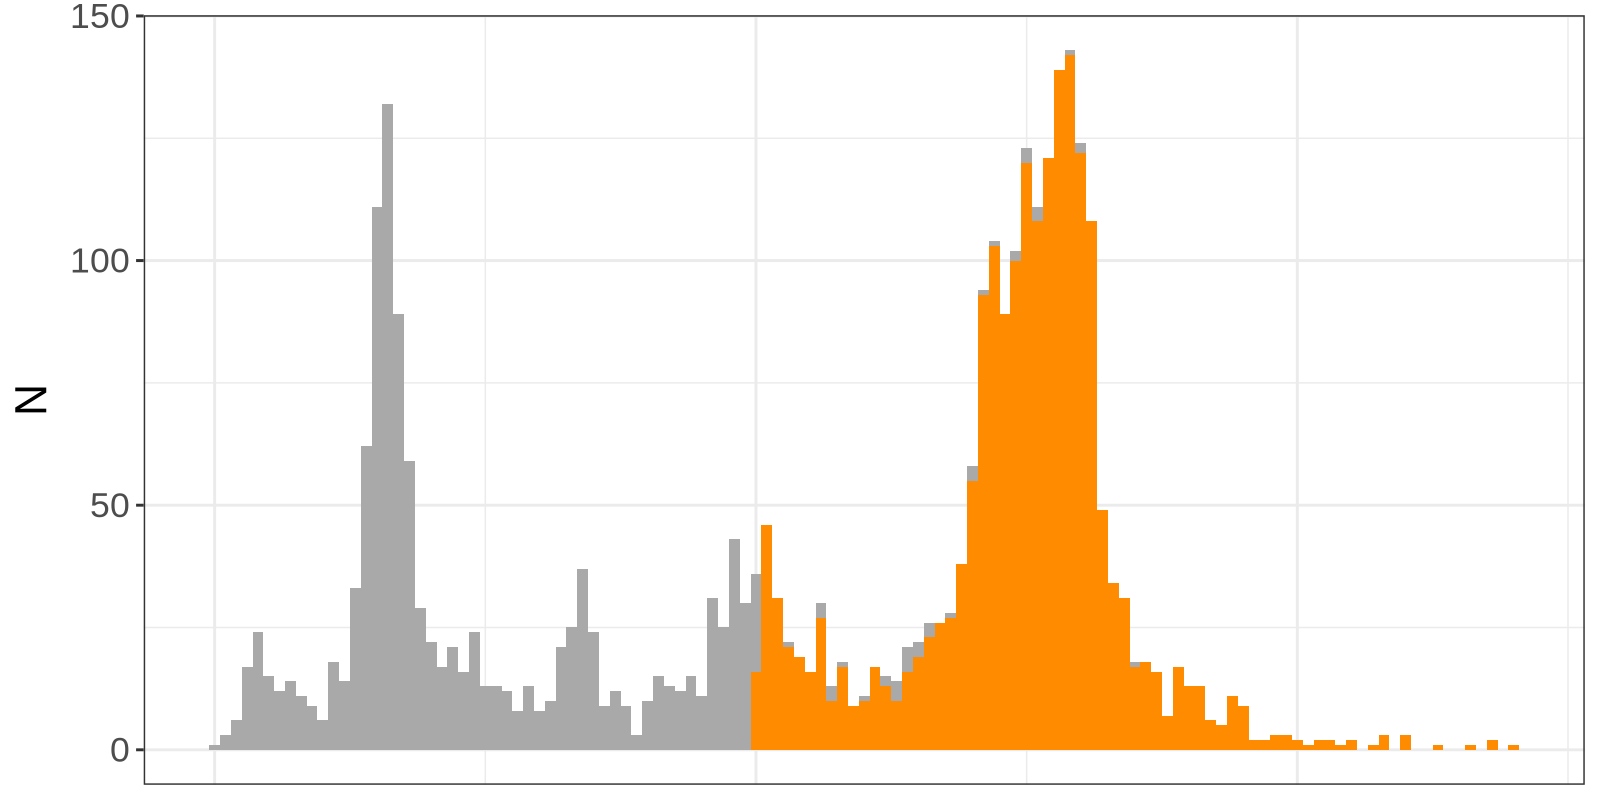

In [85]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)
hist_x

In [86]:
hist_y <- per_sample_stats_df %>%

ggplot()+
geom_histogram(aes(x = frac_cov_chrA, fill = good_sample), binwidth = 0.02)+
scale_fill_manual(values = c('darkgrey', 'darkorange'))+
scale_x_continuous()+
ylab('N')+
coord_flip()+
theme_bw() + 
theme(
    text = element_text(size = 16),
    legend.position="none", 
    axis.text.y=element_blank(),
    axis.ticks.y=element_blank(),
    axis.title.y=element_blank()
)

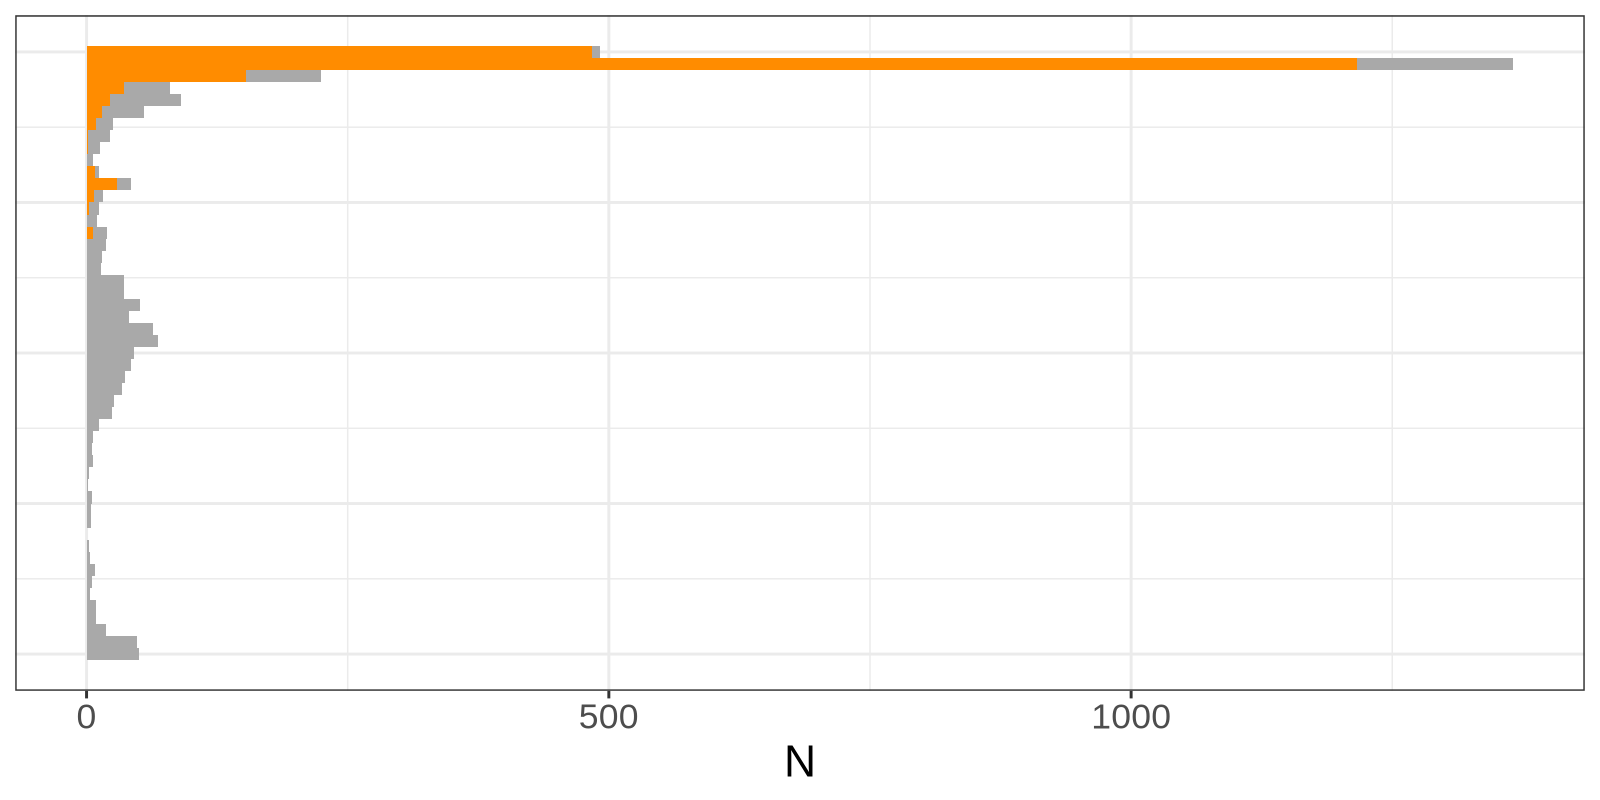

In [87]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)
hist_y

In [88]:
scatter_plot <- per_sample_stats_df %>%

ggplot()+
geom_point(aes(x = cov_chrA, y = frac_cov_chrA, color = good_frac_cov), alpha = 0.2, shape = 21, size = 3, stroke = 1)+
scale_x_log10(limits = c(0.9, 260))+
scale_y_continuous(limits = c(-0.05, 1.05))+
scale_color_manual(values = c('darkgrey', 'darkorange'))+
xlab('Depth')+
ylab('Genome length covered')+
theme_bw() + 
theme(
    text = element_text(size = 16),
    legend.position="none"
)


Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_bar()`).”


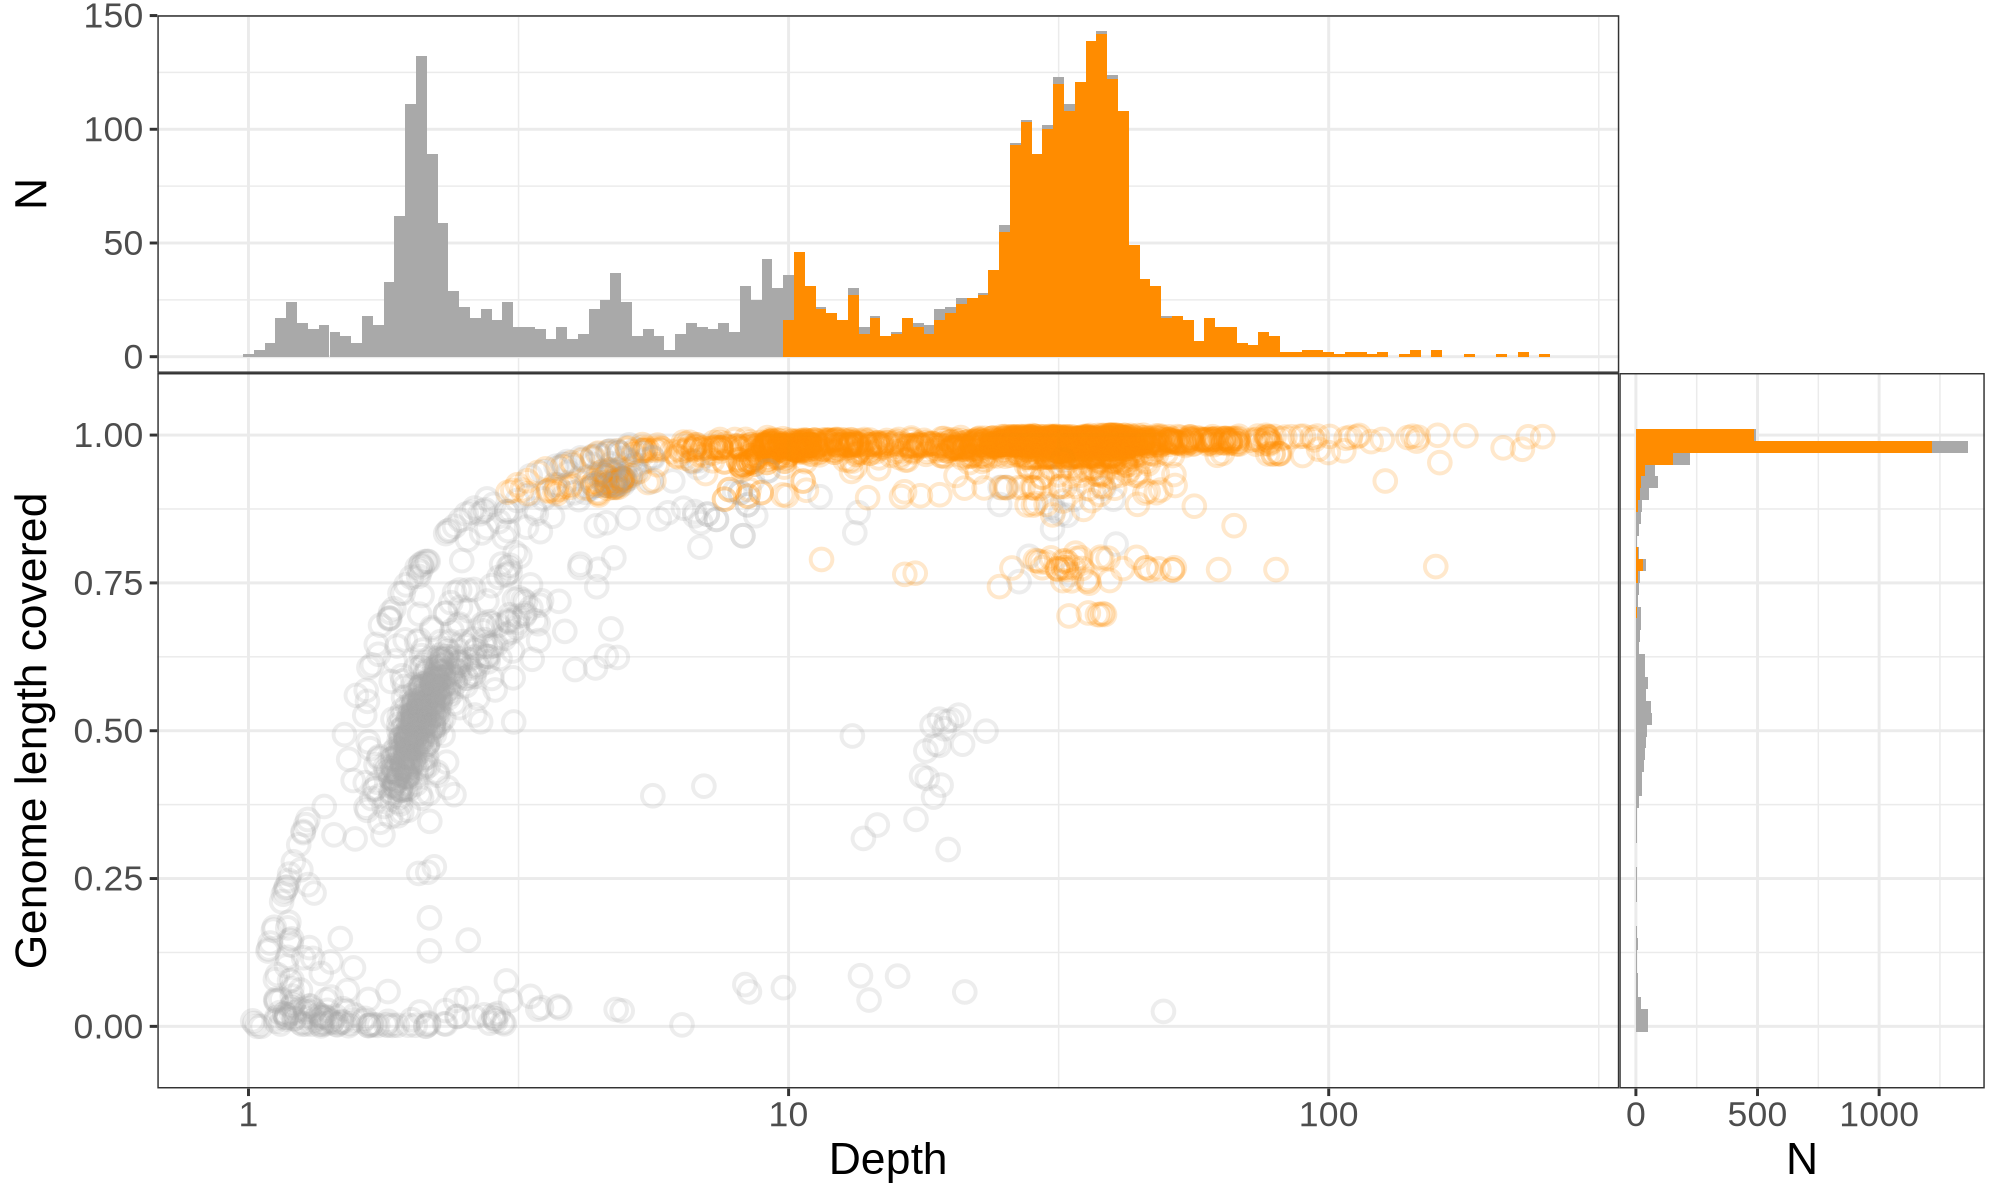

In [89]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 200)
scatter_plot %>% insert_right(hist_y, width = 0.25) %>% insert_top(hist_x, height = 0.5)

In [91]:
pdf('Fiugre1.pdf', width = 10, height = 6)
scatter_plot %>% insert_right(hist_y, width = 0.25) %>% insert_top(hist_x, height = 0.5)
dev.off()

Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_bar()`).”


agg_record_1168293426 
                    2